# Model Training - ChatKasir

- Nama: Achmad Rif'an
- Bagian: AI-1 (Model Architect)

# 1. Setup Google Colab dengan GPU

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd

# verifikasi versi
print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2


In [3]:
# verifikasi GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPU tersedia: {len(gpus) > 0}")

if gpus:
    # tampilkan detail GPU yang aktif agar terdokumentasi
    for gpu in gpus:
        print(f"Nama GPU    : {gpu.name}")

    # aktifkan memory growth - GPU tidak langsung mengambil semua VRAM
    # tapi mengalokasikan secara bertahap sesuai kebutuhan
    # ini mencegah crash "out of memory" di awal training
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth: aktif")
else:
    print("PERINGATAN: GPU tidak aktif! Cek Runtime -> Change runtime type")


GPU tersedia: True
Nama GPU    : /physical_device:GPU:0
Memory growth: aktif


# 2. Data Loading v2

In [4]:
# menyimpan url dataset ke dalam variabel
url_food = "https://drive.google.com/uc?id=1xpoFjqAT9K0uwzSpVADm_EfKqG7dxVUI"
url_slang = "https://drive.google.com/uc?id=1G14C1qcqOp06Xs1HFiorE3Us_LLtaBs7"
url_sintetis = "https://drive.google.com/uc?id=17lFTivPH4BXEd6zoa-qjpUohNmh1ELdo"

# membaca dataset
df_food = pd.read_csv(url_food)
df_slang = pd.read_csv(url_slang)
df_sintetis = pd.read_csv(url_sintetis)

In [5]:
# memuat dataset food
print(f"Total dataset food: {len(df_food)} baris.")

print("\nPratinjau 5 baris pertama dari Dataset Food:")
display(df_food.head())

Total dataset food: 18558 baris.

Pratinjau 5 baris pertama dari Dataset Food:


,name
0,abon
1,abon ayam
2,abon burger
3,abon cheese burger
4,abon goreng ayam


In [6]:
# memuat dataset slang
print(f"Total dataset slang: {len(df_slang)} baris.")

print("\nPratinjau 5 baris pertama dari Dataset Slang:")
display(df_slang.head())

Total dataset slang: 1231 baris.

Pratinjau 5 baris pertama dari Dataset Slang:


,slang,formal
0,aa,kakak
1,abanggg,abang
2,abanggku,abangku
3,abeees,habis
4,abes,habis


In [7]:
# memuat dataset sintetis
print(f"Total dataset sintetis: {len(df_sintetis)} baris.")

# memuat dataset sintetis
print("\nPratinjau 5 baris pertama dari Dataset Sintetis:")
display(df_sintetis.head())

Total dataset sintetis: 100500 baris.

Pratinjau 5 baris pertama dari Dataset Sintetis:


,input_text,product,quantity,price_satuan,pattern
0,kk mau pesen 10 daebak ken chicken wings [SEP]...,daebak ken chicken wings,10,3000,2
1,kk 3 nasi ayam betutu ya kak [SEP] noted kak n...,nasi ayam betutu,3,60000,2
2,bu mau pesen 6 indomie seafood [SEP] indomie s...,indomie seafood,6,37000,3
3,bg 9 chicken double dong [SEP] baik kak,chicken double,9,-1,1
4,bg bisa pesan 7 mie doer dong [SEP] oke mie do...,mie doer,7,42000,2


In [8]:
# memeriksa tipe data dataset sintetis
print("Informasi Dataset Sintetis:")
df_sintetis.info()

Informasi Dataset Sintetis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   input_text    100500 non-null  object
 1   product       100500 non-null  object
 2   quantity      100500 non-null  int64 
 3   price_satuan  100500 non-null  int64 
 4   pattern       100500 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.8+ MB


# 3. Tokenisasi, Padding, Label Encoding v2

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Ekstraksi Fitur (X) dan Target (y)")
X = df_sintetis['input_text'].astype(str).values

# target untuk ke-3 Output Head
y_product = df_sintetis['product'].astype(str).values
y_quantity = df_sintetis['quantity'].astype(float).values
y_price_satuan = df_sintetis['price_satuan'].astype(float).values

# normalisasi harga: dibagi 1000 agar loss seimbang dengan quantity
# nilai -1 (harga tidak diketahui) dibiarkan tetap -1
y_price_satuan = np.where(y_price_satuan != -1.0, y_price_satuan / 1000.0, -1.0)
print("Fitur dan target berhasil diekstraksi.")

Ekstraksi Fitur (X) dan Target (y)
Fitur dan target berhasil diekstraksi.


In [10]:
print("Label Encoding untuk Entitas Produk")
label_encoder = LabelEncoder()

# gabungkan seluruh nama makanan dari df_food dan df_sintetis untuk melatih encoder
# memastikan semua kosakata makanan dikenali model.
all_products = pd.concat([df_food['name'], df_sintetis['product']]).astype(str).unique()
label_encoder.fit(all_products)

# ubah target product dari string menjadi integer
y_product_encoded = label_encoder.transform(y_product)

# total kelas produk untuk arsitektur layer Dense output
num_product_classes = len(label_encoder.classes_)
print(f"LabelEncoder berhasil dibuat. Total kelas produk (num_product_classes): {num_product_classes}")

Label Encoding untuk Entitas Produk
LabelEncoder berhasil dibuat. Total kelas produk (num_product_classes): 18590


In [11]:
print("Membagi Data ke Training dan Validation (80:20)")

X_train, X_val, y_prod_train, y_prod_val, y_qty_train, y_qty_val, y_price_satuan_train, y_price_satuan_val = train_test_split(
    X, y_product_encoded, y_quantity, y_price_satuan, test_size=0.2, random_state=42
)

print(f"Data Train: {len(X_train)} baris")
print(f"Data Val  : {len(X_val)} baris")

Membagi Data ke Training dan Validation (80:20)
Data Train: 80400 baris
Data Val  : 20100 baris


In [12]:
print("Tokenisasi dan Padding Teks")

# menggunakan hyperparameter dari eksperimen Minggu 1
VOCAB_SIZE = 10000
MAX_SEQ_LEN = 30

# membuat kamus dengan mengabaikan kata asing
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

# fit hanya pada X_train agar tidak ada kebocoran data (data leakage)
tokenizer.fit_on_texts(X_train)

# mengubah teks huruf menjadi urutan angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# menyamakan panjang kalimat ke 30 token, diisi 0 jika kurang
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f"Tokenisasi & Padding selesai. Dimensi input model: {X_train_padded.shape}")

Tokenisasi dan Padding Teks
Tokenisasi & Padding selesai. Dimensi input model: (80400, 30)


# 4. Arsitektur Model v2
Layer Embedding -> Layer Shared Bi-LSTM -> Layer Dense multi-output menggunakan TensorFlow Functional API

In [13]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

# Membangun Arsitektur Model v2 ChatKasir

# hyperparameter dari eksplorasi dataset
EMBEDDING_DIM = 128
LSTM_UNITS = 64

# INPUT LAYER
# menerima array token angka dengan panjang tetap (MAX_SEQ_LEN = 30)
input_layer = Input(shape=(MAX_SEQ_LEN,), name="input_tokens")

# EMBEDDING LAYER
# mask_zero=True agar padding (0) otomatis diabaikan oleh LSTM
x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="embedding"
)(input_layer)

# SHARE BIDIRECTIONAL LSTM
# membaca kalimat dari kiri-ke-kanan dan kanan-ke-kiri sekaligus
# return_sequences=False karena hanya butuh 1 ringkasan akhir
x = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=False),
    name="bi_lstm"
)(x)

# DROPOUT LAYER
# mematikan 30% neuron secara acak untuk mencegah overfitting
x = Dropout(0.3, name="dropout")(x)

# SHARED DENSE LAYER
shared_dense = Dense(128, activation="relu", name="shared_dense")(x)

# OUTPUT HEADS (Multi-Output)
# Head 1: Product
# klasifikasi multi-kelas (Softmax) dengan total 18.558 kelas
out_product = Dense(num_product_classes, activation="softmax", name="product")(shared_dense)

# Head 2: Quantity
# regresi jumlah (ReLU memastikan tidak ada jumlah negatif)
out_quantity = Dense(1, activation="relu", name="quantity")(shared_dense)

# Head 3: Price
# regresi harga satuan
# menambah dense layer khusus
# untuk mempelajari nominal angka sebelum mengeluarkan prediksi final
price_features = Dense(64, activation="relu", name="price_extra_dense")(shared_dense)
out_price = Dense(1, activation="relu", name="price_satuan")(price_features)

# BUILD MODEL
# menyatukan semua komponen menjadi model
model = Model(
    inputs=input_layer,
    outputs=[out_product, out_quantity, out_price],
    name="ChatKasir_Extractor_v1"
)

# ringkasan arsitektur
# jumlah parameter dan koneksi antar layer
model.summary()

Model: "ChatKasir_Extractor_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_tokens        │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 128)   │  1,280,000 │ input_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30)        │          0 │ input_tokens[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm             │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bi_lstm[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 128)       │     16,512 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_extra_dense   │ (None, 64)        │      8,256 │ shared_dense[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product (Dense)     │ (None, 18590)     │  2,398,110 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantity (Dense)    │ (None, 1)         │        129 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_satuan        │ (None, 1)         │         65 │ price_extra_dens… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,801,888 (14.50 MB)

 Trainable params: 3,801,888 (14.50 MB)

 Non-trainable params: 0 (0.00 B)

# 5. Optimizer, Loss Function, Metrik Akurasi v2

In [14]:
# mendefinisikan Custom Loss (MaskedPriceLoss)
class MaskedPriceLoss(tf.keras.losses.Loss):
    """
    Custom Loss Function untuk output head 'price_price'.
    Mengecualikan baris dengan price_satuan = -1 (harga tidak diketahui)
    dari perhitungan loss agar model tidak belajar pola yang keliru.
    """
    def __init__(self, name="masked_price_loss"):
        super().__init__(name=name)
        self.NULL_INDICATOR = -1.0

    def call(self, y_true, y_pred):
        # buat mask
        # True (1.0) untuk baris yang punya harga valid (bukan -1)
        mask = tf.cast(
            tf.not_equal(y_true, self.NULL_INDICATOR),
            dtype=tf.float32
        )

        # hitung squared error untuk semua baris
        squared_error = tf.square(y_true - y_pred)

        # terapkan mask
        # baris null (-1) akan dikalikan 0 sehingga error-nya = 0
        masked_error = squared_error * mask

        # Rata-ratakan loss berdasarkan jumlah baris valid saja
        # tf.maximum untuk menghindari error pembagian dengan nol (Division by Zero)
        n_valid = tf.maximum(tf.reduce_sum(mask), 1.0)
        loss = tf.reduce_sum(masked_error) / n_valid

        return loss

print("MaskedPriceLoss berhasil didefinisikan")

MaskedPriceLoss berhasil didefinisikan


In [15]:
# Kompilasi Model

# menggunakan bobot standar 1.0 dulu untuk baseline
model.compile(
    optimizer="adam",

    # loss function tiap output
    loss={
        # Head 1 (Product): Klasifikasi multi-kelas dengan label integer
        "product": tf.keras.losses.SparseCategoricalCrossentropy(),

        # Head 2 (Quantity): Regresi angka kontinu, menghukum error besar
        "quantity": tf.keras.losses.MeanSquaredError(),

        # Head 3 (Price Satuan): Regresi menggunakan custom loss
        "price_satuan": MaskedPriceLoss(),
    },

    # bobot tiap loss terhadap total loss
    loss_weights={
        "product": 1.0,
        "quantity": 1.0,
        "price_satuan": 1.0,
    },

    # metrik evaluasi untuk masing-masing output head
    metrics={
        "product": ['accuracy'],
        "quantity": ['mae'],  # Mean Absolute Error agar selisih mudah dibaca
        "price_satuan": ['mae'],  # MAE untuk harga satuan
    }
)

print("Model berhasil dikompilasi dan siap dilatih")

Model berhasil dikompilasi dan siap dilatih


# 6. Training Iterasi v2

In [16]:
print("=== Memulai Training Baseline (Iterasi 2) ===")

# menetapkan hyperparameter dasar untuk baseline
# 20 epochs untuk melihat tren konvergensi awal
EPOCHS = 20
BATCH_SIZE = 128

history = model.fit(
    x=X_train_padded,
    y={
        "product": y_prod_train,  # target untuk klasifikasi produk
        "quantity": y_qty_train,  # target untuk regresi kuantitas
        "price_satuan": y_price_satuan_train  # target untuk regresi harga satuan
    },

    validation_data=(
        X_val_padded,
        {
            "product": y_prod_val,
            "quantity": y_qty_val,
            "price_satuan": y_price_satuan_val
        }
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

=== Memulai Training Baseline (Iterasi 2) ===
Epoch 1/20
629/629 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 63599.7422 - price_satuan_loss: 63504.6094 - price_satuan_mae: 22.3985 - product_accuracy: 0.0011 - product_loss: 7.1471 - quantity_loss: 9.5357 - quantity_mae: 2.6228 - val_loss: 56810.6992 - val_price_satuan_loss: 56454.9922 - val_price_satuan_mae: 21.9701 - val_product_accuracy: 0.0012 - val_product_loss: 7.0167 - val_quantity_loss: 8.2277 - val_quantity_mae: 2.5006
Epoch 2/20
629/629 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 57693.0586 - price_satuan_loss: 57606.1289 - price_satuan_mae: 22.0639 - product_accuracy: 0.0016 - product_loss: 7.0204 - quantity_loss: 8.5951 - quantity_mae: 2.5285 - val_loss: 56996.1445 - val_price_satuan_loss: 56638.8398 - val_price_satuan_mae: 21.8190 - val_product_accuracy: 0.0013 - val_product_loss: 7.0049 - val_quantity_loss: 8.2855 - val_quantity_mae: 2.5014
Epoch 3/20
629/629 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 57581.9336 - price_satua

# 7. Performa Training v2

In [17]:
print("=== Pencatatan Baseline Performa Training 2 ===")

# mengambil hasil evaluasi (validation) dari epoch yang paling terakhir
last_epoch_idx = EPOCHS - 1

val_loss = history.history['val_loss'][last_epoch_idx]
val_prod_acc = history.history['val_product_accuracy'][last_epoch_idx]
val_qty_mae = history.history['val_quantity_mae'][last_epoch_idx]
val_price_satuan_mae = history.history['val_price_satuan_mae'][last_epoch_idx]

print("BASELINE PERFORMA MODEL v2 (VALIDATION SET)")
print("="*50)
print(f"Total Validation Loss : {val_loss:.4f}")
print(f"Akurasi Produk        : {val_prod_acc*100:.2f}% (Target Akhir: >= 85%)")
print(f"MAE Quantity          : {val_qty_mae:.4f} porsi")
print(f"MAE Price Satuan      : {val_price_satuan_mae:.4f} (dalam skala x Rp1.000)")
print("Iterasi training ke-2 selesai")

=== Pencatatan Baseline Performa Training 2 ===
BASELINE PERFORMA MODEL v2 (VALIDATION SET)
Total Validation Loss : 57699.4453
Akurasi Produk        : 0.06% (Target Akhir: >= 85%)
MAE Quantity          : 2.5028 porsi
MAE Price Satuan      : 21.6342 (dalam skala x Rp1.000)
Iterasi training ke-2 selesai


# 8. Curva Training Iterasi v2

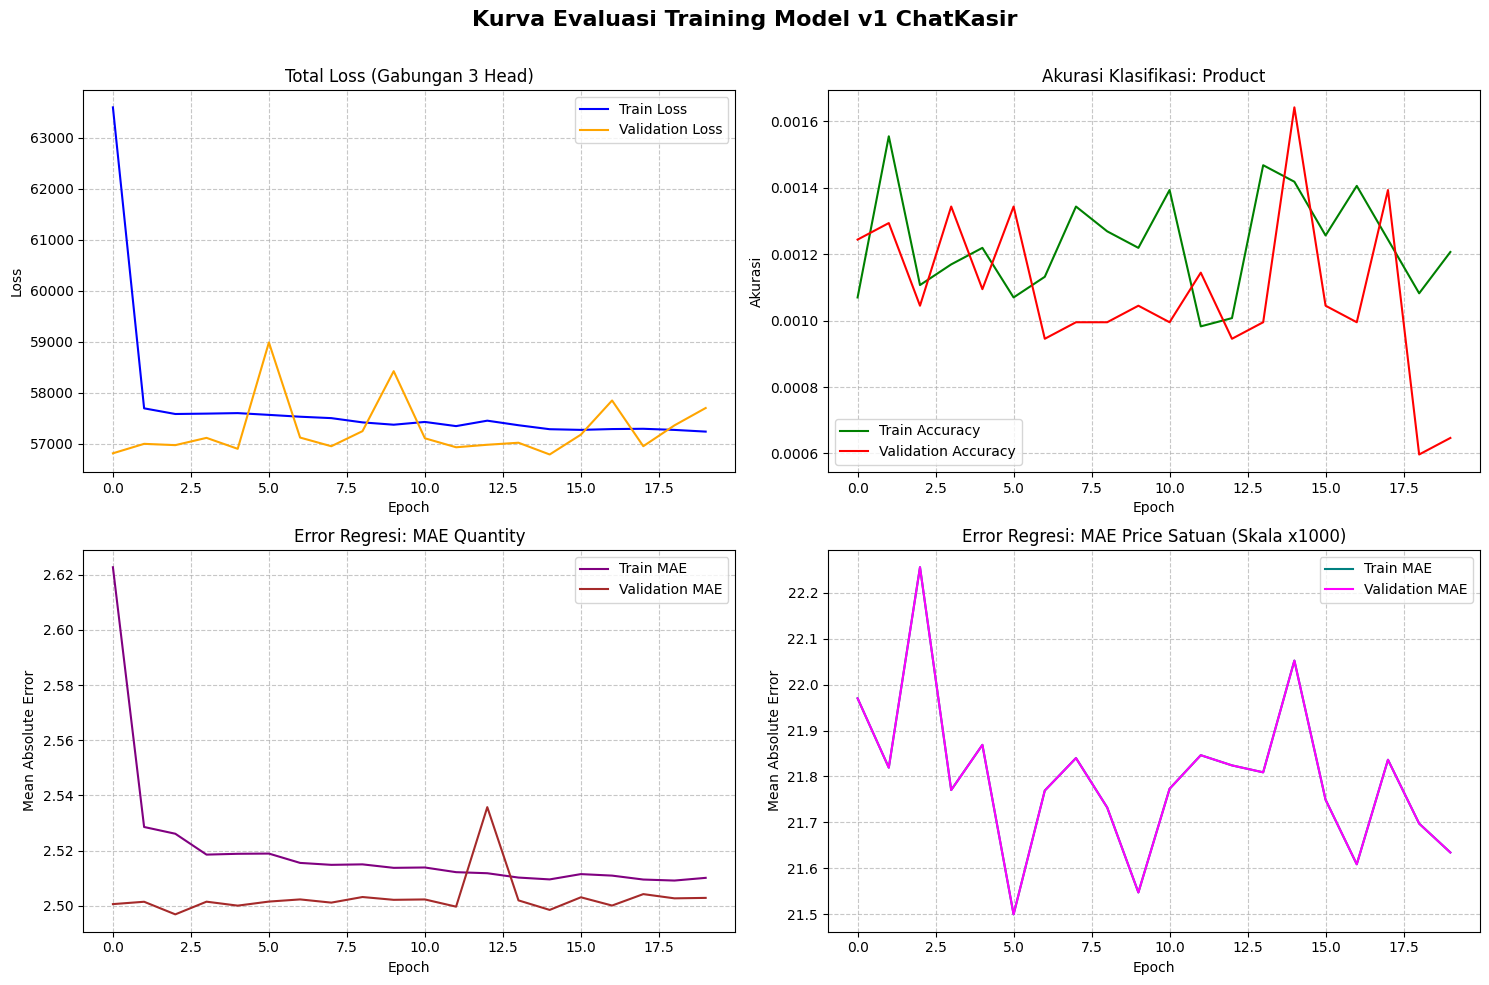

In [18]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # membuat grid grafik 2x2
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Kurva Evaluasi Training Model v1 ChatKasir', fontsize=16, fontweight='bold')

    # Plot Total Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
    axes[0, 0].set_title('Total Loss (Gabungan 3 Head)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Plot Akurasi Product
    axes[0, 1].plot(history.history['product_accuracy'], label='Train Accuracy', color='green')
    axes[0, 1].plot(history.history['val_product_accuracy'], label='Validation Accuracy', color='red')
    axes[0, 1].set_title('Akurasi Klasifikasi: Product')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Akurasi')
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Plot MAE Quantity
    axes[1, 0].plot(history.history['quantity_mae'], label='Train MAE', color='purple')
    axes[1, 0].plot(history.history['val_quantity_mae'], label='Validation MAE', color='brown')
    axes[1, 0].set_title('Error Regresi: MAE Quantity')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Mean Absolute Error')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Plot MAE Price Satuan
    axes[1, 1].plot(history.history['val_price_satuan_mae'], label='Train MAE', color='teal')
    axes[1, 1].plot(history.history['val_price_satuan_mae'], label='Validation MAE', color='magenta')
    axes[1, 1].set_title('Error Regresi: MAE Price Satuan (Skala x1000)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Mean Absolute Error')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    # merapikan jarak antar grafik
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# panggil fungsi
plot_training_history(history)

# 9. Analisis Error Model v2

In [19]:
import pandas as pd
import numpy as np

print("Melakukan prediksi pada Validation Set...")
# prediksi dari model v2
predictions = model.predict(X_val_padded)

# output 0: Product (ambil indeks probabilitas tertinggi dengan argmax)
pred_product_idx = np.argmax(predictions[0], axis=1)
# output 1: Quantity (bulatkan karena jumlah pesanan pasti integer)
pred_quantity = np.round(predictions[1].flatten())
# output 2: Price Satuan (flatten array 2D ke 1D)
pred_price = predictions[2].flatten()

# kembalikan label produk ke bentuk teks (inverse transform)
true_product_labels = label_encoder.inverse_transform(y_prod_val)
pred_product_labels = label_encoder.inverse_transform(pred_product_idx)

# buat dataframe untuk membandingkan prediksi dengan nilai asli
df_errors = pd.DataFrame({
    'teks_input': X_val, # teks chat mentah sebelum tokenisasi
    'true_product': true_product_labels,
    'pred_product': pred_product_labels,
    'true_quantity': y_qty_val,
    'pred_quantity': pred_quantity,
    # kembalikan harga ke skala rupiah penuh (* 1000)
    'true_price': y_price_satuan_val * 1000,
    'pred_price': pred_price * 1000
})

# hitung Error
df_errors['product_match'] = df_errors['true_product'] == df_errors['pred_product']
df_errors['quantity_error'] = np.abs(df_errors['true_quantity'] - df_errors['pred_quantity'])

# untuk harga, abaikan (set error 0) baris yang harganya -1
df_errors['price_error'] = np.where(
    df_errors['true_price'] >= 0,
    np.abs(df_errors['true_price'] - df_errors['pred_price']),
    0
)

# tampilkan analisis kesalahan
print("\nIDENTIFIKASI POLA KEGAGALAN MODEL V2")

print("\nENTITAS PRODUK (Top 5 Kesalahan)")
salah_produk = df_errors[~df_errors['product_match']]

print(f"Total baris salah tebak produk: {len(salah_produk)} dari {len(df_errors)}")
display(salah_produk[['teks_input', 'true_product', 'pred_product']].head())

Melakukan prediksi pada Validation Set...
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
IDENTIFIKASI POLA KEGAGALAN MODEL V2

ENTITAS PRODUK (Top 5 Kesalahan)
Total baris salah tebak produk: 20087 dari 20100


,teks_input,true_product,pred_product
0,minta 4 rempela goreng plus nasi dong kak [SEP...,rempela goreng plus nasi,pancong meses susu s
1,4 nasi penyetan bebek ya kak,nasi penyetan bebek,pancong meses susu s
2,7 pempek ya [SEP] pempek 75.000 ya kak jadi rp...,pempek,pancong meses susu s
3,pak bisa pesan 10 crunchy vegan fried chicken ...,crunchy vegan fried chicken spicy,pancong meses susu s
4,kak mau pesen 3 kopi sanger kak [SEP] baik kak,kopi sanger,pancong meses susu s


In [20]:
print("\nENTITAS QUANTITY (Top 5 Error Terbesar)")
display(df_errors.sort_values(by='quantity_error', ascending=False)[['teks_input', 'true_quantity', 'pred_quantity', 'quantity_error']].head())


ENTITAS QUANTITY (Top 5 Error Terbesar)


,teks_input,true_quantity,pred_quantity,quantity_error
11308,kak mau order 10 bakso rudal nih [SEP] siap ka...,10.0,5.0,5.0
6980,kak mauu order 10 koloke nasi ya kak [SEP] sia...,10.0,5.0,5.0
17923,10 cupcakes flower set ya [SEP] baik kak,10.0,5.0,5.0
6978,mbak 10 thai tea lychee kak [SEP] oke kak thai...,10.0,5.0,5.0
17927,boleh pesan 10 biasa telor ayam sosis ya [SEP]...,10.0,5.0,5.0


In [21]:
print("\nENTITAS HARGA (Top 5 Error Terbesar)")
# Hanya tampilkan baris yang memang memiliki harga valid
display(df_errors[df_errors['true_price'] >= 0].sort_values(by='price_error', ascending=False)[['teks_input', 'true_price', 'pred_price', 'price_error']].head())


ENTITAS HARGA (Top 5 Error Terbesar)


,teks_input,true_price,pred_price,price_error
17740,1 nasi bakar [SEP] noted kak nasi bakar rp75rb...,75000.0,36120.312500,38879.687500
18394,8 teh jasmine kecil [SEP] noted kak teh jasmin...,75000.0,36144.652344,38855.347656
17812,mau pesen 3 duo paha ayam kak [SEP] oke kak du...,75000.0,36152.609375,38847.390625
10397,8 chicken steak cordon bleu nih [SEP] baik kak...,75000.0,36158.882812,38841.117188
436,6 nasi goreng cabe ijo dong kak [SEP] siap kak...,75000.0,36160.253906,38839.746094
